In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras
from keras.datasets import mnist
from tensorflow.math import confusion_matrix

In [2]:
(X_train,y_train),(X_test,y_test)=mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


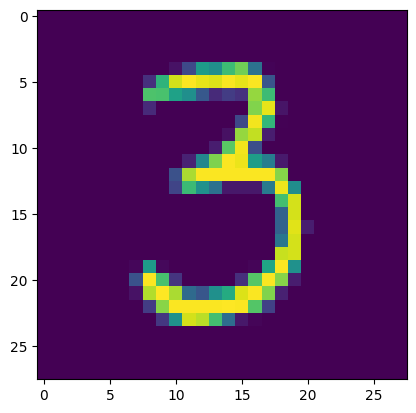

3


In [4]:
plt.imshow(X_train[50])
plt.show()
print(y_train[50])

In [6]:
print(np.unique(y_train))
print(np.unique(y_test))

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]


In [7]:
#scaling the values because the values are between 0 and 255 lets make it betwen 0 and 1
X_train=X_train/255
X_test=X_test/255

In [10]:
#setting up the layers for neural netwrok
model=keras.Sequential([keras.layers.Flatten(input_shape=(28,28)),
                        keras.layers.Dense(50,activation='relu'),
                        keras.layers.Dense(50,activation='relu'),
                        keras.layers.Dense(10,activation='sigmoid')

                        ])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
model.compile(optimizer='Adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [12]:
model.fit(X_train,y_train,epochs=10,validation_split=0.1)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9093 - loss: 0.3056 - val_accuracy: 0.9545 - val_loss: 0.1508
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9563 - loss: 0.1453 - val_accuracy: 0.9662 - val_loss: 0.1152
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9678 - loss: 0.1066 - val_accuracy: 0.9720 - val_loss: 0.1012
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9744 - loss: 0.0834 - val_accuracy: 0.9743 - val_loss: 0.0944
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9794 - loss: 0.0678 - val_accuracy: 0.9747 - val_loss: 0.0944
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9829 - loss: 0.0556 - val_accuracy: 0.9732 - val_loss: 0.0962
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9856 - loss: 0.0470 - val_accuracy: 0.9725 - val_loss: 0.0997
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9874 - loss: 0.0402 - 

In [13]:
loss,accuracy=model.evaluate(X_test,y_test)
print(accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9711 - loss: 0.1132
0.9710999727249146


In [14]:
print(X_test.shape)

(10000, 28, 28)


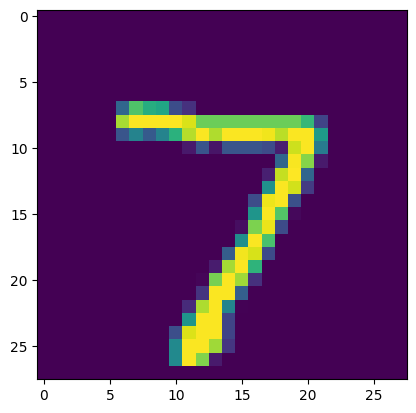

In [15]:
plt.imshow(X_test[0])
plt.show()

In [16]:
print(y_test[0])

7


In [17]:
y_pred=model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [18]:
y_pred.shape

(10000, 10)

In [19]:
print(y_pred[0])

[5.24672669e-06 1.06918684e-04 3.49356353e-01 9.98764217e-01
 3.23952798e-09 1.75852310e-02 4.28277396e-08 9.99976814e-01
 2.32520178e-01 3.62813741e-01]


In [20]:
#converting the clas probabilities to labels
label=[np.argmax(i) for i in y_pred]
print(label)

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4), np.int64(1), np.int64(4), np.int64(9), np.int64(5), np.int64(9), np.int64(0), np.int64(6), np.int64(9), np.int64(0), np.int64(1), np.int64(5), np.int64(9), np.int64(7), np.int64(8), np.int64(4), np.int64(9), np.int64(6), np.int64(6), np.int64(5), np.int64(4), np.int64(0), np.int64(7), np.int64(4), np.int64(0), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(4), np.int64(7), np.int64(2), np.int64(7), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(7), np.int64(4), np.int64(2), np.int64(3), np.int64(5), np.int64(1), np.int64(2), np.int64(4), np.int64(4), np.int64(6), np.int64(3), np.int64(5), np.int64(5), np.int64(6), np.int64(0), np.int64(4), np.int64(1), np.int64(9), np.int64(5), np.int64(7), np.int64(8), np.int64(9), np.int64(3), np.int64(7), np.int64(4), np.int64(8), np.int64(4), np.int64(3), np.int64(0), np.int64(7), np.int64(0), np.int64(2), np.int64(9), np.int64(1), np.int64(7), np.int64(3)

In [21]:
conf_mat=confusion_matrix(y_test,label)
print(conf_mat)


tf.Tensor(
[[ 957    0    1    1    1    6    5    1    5    3]
 [   0 1127    2    1    0    1    2    0    2    0]
 [   1    3  966   24    3    1    1   12   21    0]
 [   0    0    0  992    1    4    0    2    7    4]
 [   0    0    1    2  955    0    5    9    2    8]
 [   2    0    0   10    0  870    2    2    4    2]
 [   2    3    3    1    2   12  930    0    5    0]
 [   0    4    7    5    0    0    0 1000    3    9]
 [   1    0    2    6    3    8    1    4  944    5]
 [   1    4    0    9    7    8    0    8    2  970]], shape=(10, 10), dtype=int32)


Text(50.722222222222214, 0.5, 'Truth')

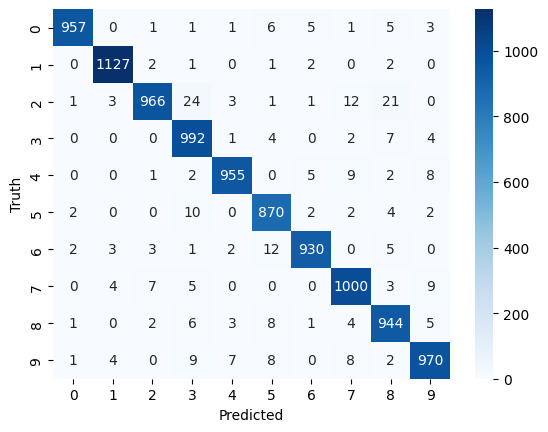

In [22]:
sns.heatmap(conf_mat,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [23]:
input_image=cv2.imread('/content/MNIST_digit.png')

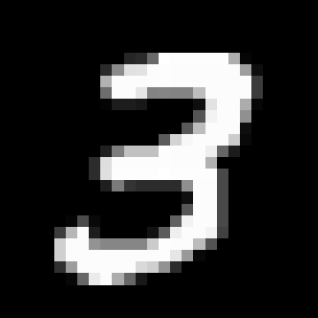

In [25]:
cv2_imshow(input_image)

In [26]:
input_image.shape

(318, 318, 3)

In [28]:
#converting the image into grayscale image
grayscale=cv2.cvtColor(input_image,cv2.COLOR_BGR2GRAY)

In [29]:
input_image_resize=cv2.resize(grayscale,(28,28))

In [30]:
input_image_resize.shape

(28, 28)

In [31]:
cv2_imshow(input_image_resize)

In [32]:
input_image_resize=input_image_resize/255

In [33]:
image_reshape=np.reshape(input_image_resize,[1,28,28])

In [35]:
input_prediction=model.predict(image_reshape)
print(input_prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
[[3.3011029e-14 1.2109333e-03 5.6468667e-07 1.0000000e+00 2.1989309e-12
  1.3055280e-02 2.9554822e-19 2.0171448e-05 9.7928166e-01 9.8662817e-01]]


In [37]:
input_pred_label=np.argmax(input_prediction)
print(input_pred_label)

3


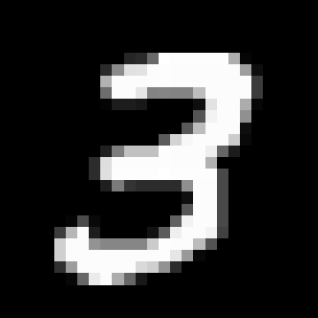

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
[[3.3011029e-14 1.2109333e-03 5.6468667e-07 1.0000000e+00 2.1989309e-12
  1.3055280e-02 2.9554822e-19 2.0171448e-05 9.7928166e-01 9.8662817e-01]]
3


In [38]:
input_image=cv2.imread('/content/MNIST_digit.png')
cv2_imshow(input_image)
#converting the image into grayscale image
grayscale=cv2.cvtColor(input_image,cv2.COLOR_BGR2GRAY)
input_image_resize=cv2.resize(grayscale,(28,28))
input_image_resize=input_image_resize/255
image_reshape=np.reshape(input_image_resize,[1,28,28])
input_prediction=model.predict(image_reshape)
print(input_prediction)
input_pred_label=np.argmax(input_prediction)
print(input_pred_label)